Langkah Ke-1 Inisialisasi Library

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter
from IPython.display import display

from sklearn.metrics import silhouette_score, davies_bouldin_score
import os

Langkah Ke-2 Load Dataset + Data Preprocessing (Data Cleansing)

In [56]:
# ── Load Dataset ──────────────────────────────────────────────
df = pd.read_excel('data/1_Data_Raw/Dataset.xlsx')

print("=== INFO AWAL ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Variabel : {df.shape[1]}")
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ── STEP 1: Fill NA dengan 0 (hanya kolom numerik data) ──────
kolom_numerik = [
    'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen',
    'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound',
    'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus',
    'Jumlah Sitasi Per Prodi',
    'Jumlah Artikel yang Melibatkan Kolaborator Internasional',
    'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik'
]
df[kolom_numerik] = df[kolom_numerik].fillna(0)

# ── STEP 2: Pastikan tipe data numerik (antisipasi data terbaca sebagai string) ──
df[kolom_numerik] = df[kolom_numerik].apply(pd.to_numeric, errors='coerce').fillna(0)

# ── STEP 3: Identifikasi & hapus baris Mahasiswa = 0 atau Dosen = 0 ──
mask_hapus = (df['Jumlah Mahasiswa'] == 0) | (df['Jumlah Dosen'] == 0)

print(f"\n=== BARIS YANG DIHAPUS ({mask_hapus.sum()} baris) ===")
# Sesuaikan kolom identitas dengan nama kolom di dataset Anda
print(df[mask_hapus][['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Dosen']])

df_clean = df[~mask_hapus].reset_index(drop=True)
print(f"\nJumlah baris setelah cleaning: {df_clean.shape[0]}")
print(f"Jumlah variabel setelah cleaning: {df_clean.shape[1]}")

# Simpan hasil cleaning
df_clean.to_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx', index=False)
df_clean.to_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv', index=False)

=== INFO AWAL ===
Jumlah Baris : 175
Jumlah Variabel : 13

=== MISSING VALUES ===
Program Studi                                               0
Jumlah Mahasiswa                                            0
Jumlah Mahasiswa Asing                                      0
Jumlah Dosen                                                0
Jumlah Dosen Asing                                          0
Jumlah Dosen S3                                             0
Jumlah Inbound                                              0
Jumlah Outbound                                             0
Jumlah Artikel di Jurnal Terindeks Scopus                   0
Jumlah Sitasi Per Prodi                                     0
Jumlah Artikel yang Melibatkan Kolaborator Internasional    0
Jumlah Negara Kolaborator                                   0
Jumlah Institusi Unik                                       0
dtype: int64

=== BARIS YANG DIHAPUS (4 baris) ===
                                   Program Studi  Jumlah Maha

In [ ]:
data_hasil_cleansing_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx')
data_hasil_cleansing_csv = pd.read_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv')
data_hasil_cleansing_xlsx.head()
# data_hasil_cleansing_csv.head()

Langkah Ke-3 Data Preprocessing (Data Selection)

In [57]:
# ── Drop kolom yang tidak digunakan ──────────────────────────
df_selected = df_clean.drop(
    columns=['Jumlah Artikel yang Melibatkan Kolaborator Internasional']
)

print("=== KOLOM SETELAH SELEKSI ===")
print(df_selected.columns.tolist())

df_selected.to_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx', index=False)
df_selected.to_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv', index=False)

=== KOLOM SETELAH SELEKSI ===
['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen', 'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound', 'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus', 'Jumlah Sitasi Per Prodi', 'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik']


In [ ]:
data_hasil_Selection_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx')
data_hasil_Selection_csv = pd.read_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv')
data_hasil_Selection_xlsx.head()
# data_hasil_Selection_csv.head()

Langkah Ke-4 Data Preprocessing (Data Transformation)

In [58]:
df_transform = df_selected.copy()

# ── 1. Faculty / Student Ratio (FSR) ─────────────────────────
# Penyebut (Mahasiswa) dijamin > 0 setelah cleaning
df_transform['FSR'] = df_transform['Jumlah Dosen'] / df_transform['Jumlah Mahasiswa']

# ── 2. International Research Network (IRN) ──────────────────
# Penanganan khusus: ln(1) = 0 dan kasus belum kolaborasi
def hitung_irn(row):
    negara   = row['Jumlah Negara Kolaborator']
    institusi = row['Jumlah Institusi Unik']

    # Case 4: Negara=0 & Institusi=0 → belum kolaborasi internasional
    if negara == 0 and institusi == 0:
        return 0.0
    # Case 5: Institusi=1 → ln(1)=0, hindari pembagian nol
    elif institusi <= 1:
        return 0.0
    # Case 1: Normal
    else:
        return negara / np.log(institusi)

df_transform['IRN'] = df_transform.apply(hitung_irn, axis=1)

# ── 3. Citations per Paper (CPP) ─────────────────────────────
# Penanganan khusus: artikel=0 → CPP=0 (termasuk sitasi>0 yg tidak mungkin)
def hitung_cpp(row):
    artikel = row['Jumlah Artikel di Jurnal Terindeks Scopus']
    sitasi  = row['Jumlah Sitasi Per Prodi']

    if artikel == 0:
        # Case 2 (sitasi=0) & Case 3 (sitasi>0, tidak mungkin) → keduanya 0
        return 0.0
    else:
        # Case 1: artikel>0, sitasi bisa 0 (belum disitasi) → hasil tetap 0
        return sitasi / artikel

df_transform['CPP'] = df_transform.apply(hitung_cpp, axis=1)

# ── 4. Papers per Faculty (PPF) ──────────────────────────────
# Penyebut (Dosen) dijamin > 0 setelah cleaning
# Pembilang=0 → PPF=0 secara alami dari pembagian
df_transform['PPF'] = (
    df_transform['Jumlah Artikel di Jurnal Terindeks Scopus'] / df_transform['Jumlah Dosen']
)

# ── 5. Staff with PhD ─────────────────────────────────────────
df_transform['Staff_PhD (%)'] = (
    df_transform['Jumlah Dosen S3'] / df_transform['Jumlah Dosen']
) * 100

# ── 6. International Faculty Ratio ───────────────────────────
df_transform['IFR (%)'] = (
    df_transform['Jumlah Dosen Asing'] / df_transform['Jumlah Dosen']
) * 100

# ── 7. Proportion of International Students ──────────────────
df_transform['PIS (%)'] = (
    df_transform['Jumlah Mahasiswa Asing'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 8. Proportion of Inbound Exchange Students ───────────────
df_transform['Inbound (%)'] = (
    df_transform['Jumlah Inbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 9. Proportion of Outbound Exchange Students ──────────────
df_transform['Outbound (%)'] = (
    df_transform['Jumlah Outbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── Susun kolom output final ──────────────────────────────────
kolom_identitas = ['Program Studi']  # sesuaikan nama kolom Anda
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF',
            'Staff_PhD (%)', 'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final = df_transform[kolom_identitas + kolom_qs]

print("=== PREVIEW HASIL TRANSFORMASI ===")
print(df_final.head())

print("\n=== STATISTIK DESKRIPTIF VARIABEL QS ===")
print(df_final[kolom_qs].describe().round(4))

# Simpan hasil akhir preprocessing
df_final.to_excel('data/2_Data_Preprocessed/xlsx/3_Hasil_Data_Transformation.xlsx', index=False)
df_final.to_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv', index=False)


=== PREVIEW HASIL TRANSFORMASI ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1              UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2         UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   
3       UNEJ - Kenotariatan (S2)  0.020921  1.442695  2.257143  7.000000   
4  UNEJ - Pendidikan Dokter Gigi  0.042433  3.728010  4.833333  5.600000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  
3     100.000000      0.0      0.0     0.000000      0.000000  
4      46.666667      0.0      0.0     0.141443      0.000000  

=== STATISTIK DESKRIPTIF VARIABEL QS ===
            FSR       IRN       CPP       PPF  Staff_PhD (%)   IFR (%)  \
count  1

Langkah Ke-5 Cek Outlier Untuk Penentuan Metode Normalisasi

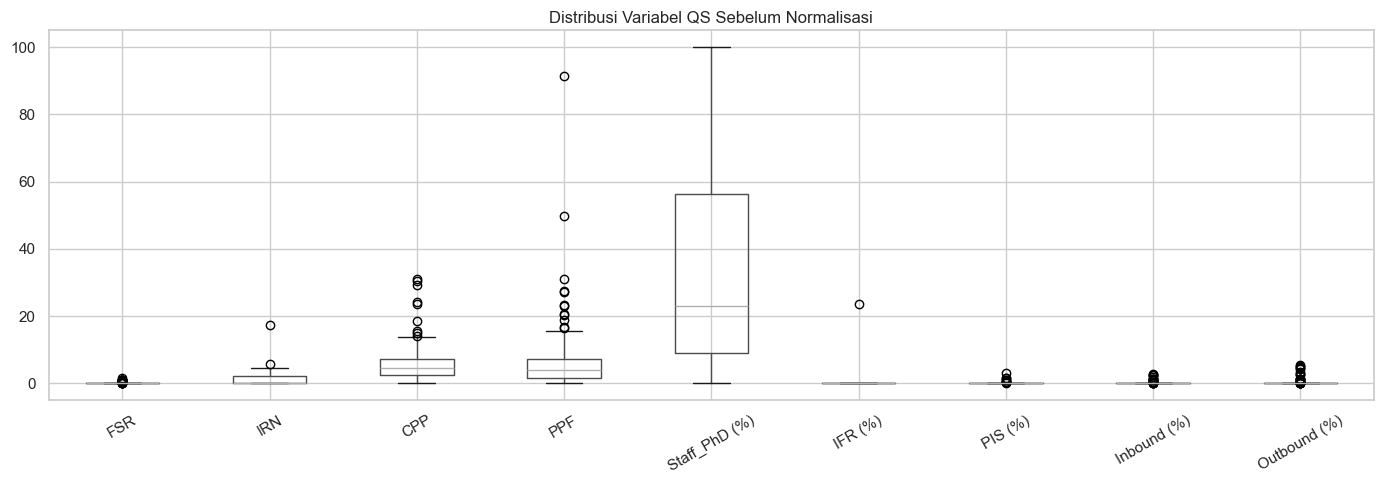

In [59]:
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)', 
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final[kolom_qs].boxplot(figsize=(14, 5), rot=30)
plt.title('Distribusi Variabel QS Sebelum Normalisasi')
plt.tight_layout()
plt.show()

# FSR, IFR, PIS, Inbound, Outbound — Kotak sangat tipis mendekati nol, artinya mayoritas program studi memang bernilai sangat kecil. Wajar untuk universitas regional.
# IRN & CPP — Ada beberapa outlier (titik bulat di atas), tapi masih dalam batas wajar.
# PPF — Ada outlier dari ~50 dan ~90, perlu diwaspadai saat normalisasi Min-Max.
# Staff_PhD (%) — Ini yang paling perlu diperhatikan. Kotak sangat besar (Q1 ≈ 0, Q3 ≈ 55, max = 100). Artinya distribusinya sangat tersebar, ada program studi dengan 0% hingga 100% dosen bergelar doktor.

Langkah ke-6 Normalisasi Menggunakan Z-Score

In [60]:
# ── 1. Load Data dari CSV ─────────────────────────────────────
df = pd.read_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv')

print("=== DATA SEBELUM NORMALISASI ===")
print(df.head(3))
print(f"\nShape: {df.shape}")

# ── 2. Definisikan kolom identitas vs kolom yang dinormalisasi ─
kolom_identitas = ['Program Studi']
kolom_qs = [
    'FSR', 'IRN', 'CPP', 'PPF',
    'Staff_PhD (%)', 'IFR (%)', 'PIS (%)',
    'Inbound (%)', 'Outbound (%)'
]

# ── 3. Terapkan Z-Score hanya pada kolom variabel QS ──────────
scaler = StandardScaler()
data_normalized = scaler.fit_transform(df[kolom_qs])

# ── 4. Susun DataFrame hasil normalisasi ──────────────────────
df_normalized = pd.DataFrame(data_normalized, columns=kolom_qs)
df_normalized.insert(0, 'Program Studi', df['Program Studi'].values)

# ── 5. Buat folder normalized jika belum ada ──────────────────
os.makedirs('data/3_Data_Normalized', exist_ok=True)

# ── 6. Simpan ke CSV dan Excel ────────────────────────────────
output_csv  = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.csv'
output_xlsx = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx'

df_normalized.to_csv(output_csv, index=False)
df_normalized.to_excel(output_xlsx, index=False)

# ── 7. Preview hasil ──────────────────────────────────────────
print("\n=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===")
print(df_normalized.head())

print("\n=== STATISTIK DESKRIPTIF SETELAH NORMALISASI ===")
print(df_normalized[kolom_qs].describe().round(4))

# ── 8. Verifikasi kebenaran Z-Score ───────────────────────────
# Mean setiap kolom seharusnya ≈ 0
# Std setiap kolom seharusnya ≈ 1
print("\n=== VERIFIKASI HASIL (mean ≈ 0 dan std ≈ 1 = BERHASIL) ===")
verifikasi = pd.DataFrame({
    'Mean'  : df_normalized[kolom_qs].mean().round(6),
    'Std'   : df_normalized[kolom_qs].std().round(6)
})
print(verifikasi)

print(f"\nFile berhasil disimpan:")
print(f"  → {output_csv}")
print(f"  → {output_xlsx}")

=== DATA SEBELUM NORMALISASI ===
              Program Studi       FSR       IRN       CPP       PPF  \
0  UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1         UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2    UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  

Shape: (171, 10)

=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter -0.192951  0.451346  0.051053 -0.327208   
1              UNEJ - Ilmu Hukum -0.393983  0.845670 -0.790350 -0.599758   
2         UNEJ - Ilmu Hukum (S2) -0.436250 -0.625979 -0.744981 -0.028312   
3       UNEJ - Kenotariatan (S2) -0.422954  

Langkah Ke-7 PENENTUAN NILAI K (ELBOW + SILHOUETTE) 

Aman Lolos Gemini Pro

Text : Saya sangat setuju. Kode tersebut sudah sangat komprehensif, tangguh secara matematis, dan memang tidak perlu direvisi lagi.

Link : https://gemini.google.com/app/55318b9a883859c2

Aman Lolos Claude Maks + Pemikiran 

Text : CELL 7 — Penentuan Nilai K: ✅ Sudah Benar

Link : https://claude.ai/chat/d370a98f-cb29-4173-8509-9dee94e5db16

Jumlah data (N) = 171

⚠️  PERINGATAN PENTING: Untuk SEMUA nilai K dari 3 hingga 15,
   selalu terdapat minimal 1 cluster dengan anggota ≤2.
   Ini menunjukkan data memiliki outlier ekstrem yang secara konsisten
   diisolasi oleh K-Means. Pertimbangkan mendokumentasikan cluster
   singleton sebagai 'klaster eksklusif outlier' dalam interpretasi hasil.

=== TABEL RINGKASAN EVALUASI K ===


C:\Users\satri\AppData\Local\Temp\ipykernel_17380\2088235207.py:44: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


,K,WCSS,Silhouette,Cluster_Terkecil,Distribusi_Ukuran,Flag
0,1,1539.0000,NaN,171,[171],
1,2,1307.1687,0.3381,46,"[125, 46]",
2,3,1134.9922,0.3386,1,"[127, 43, 1]",⚠️n≤2
3,4,1008.1683,0.3670,1,"[131, 35, 4, 1]",⚠️n≤2
4,5,857.2455,0.3876,1,"[112, 38, 11, 9, 1]",⚠️n≤2
5,6,742.0603,0.3915,1,"[106, 28, 16, 11, 9, 1]",⚠️n≤2
6,7,613.2301,0.4257,1,"[108, 31, 11, 9, 8, 3, 1]",⚠️n≤2
7,8,516.3955,0.4079,1,"[103, 25, 11, 10, 9, 9, 3, 1]",Elbow ⚠️n≤2
8,9,435.6887,0.4453,1,"[104, 28, 11, 9, 8, 6, 3, 1, 1]",SilMax ⚠️n≤2
9,10,370.1159,0.3708,1,"[71, 36, 27, 11, 9, 9, 3, 3, 1, 1]",⚠️n≤2



K optimal (Elbow Method)    : 8
K optimal (Silhouette Score): 9


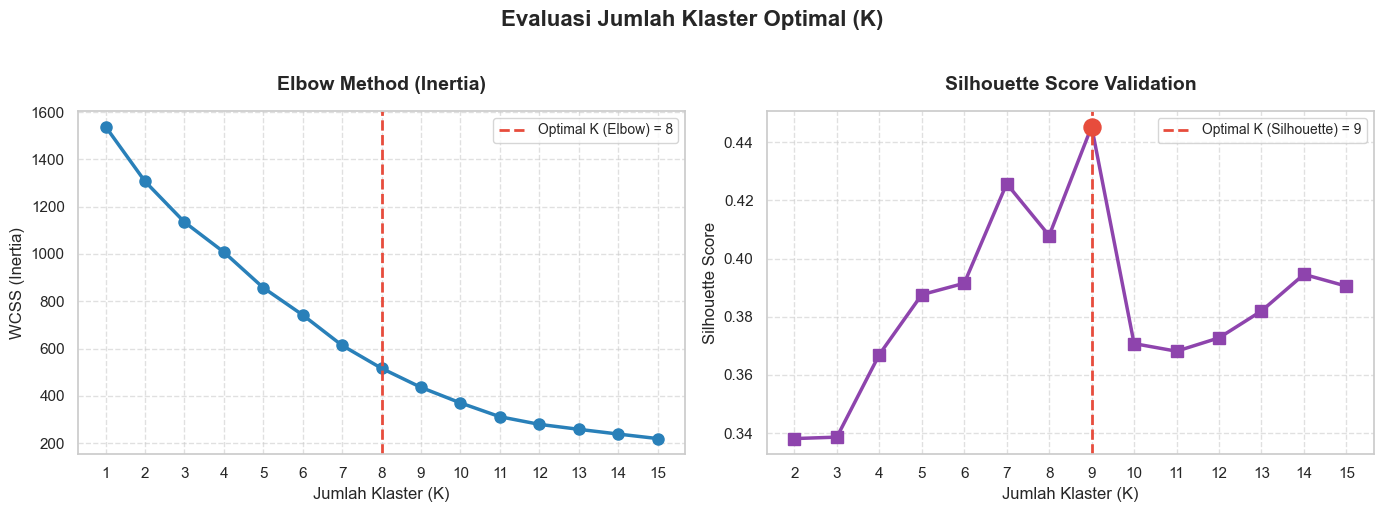

In [66]:
# ============================================================
# CELL 7: PENENTUAN NILAI K (ELBOW + SILHOUETTE)
# ============================================================

# ── 0. Load Data (eksplisit, tidak bergantung pada cell sebelumnya) ──
df_normalized = pd.read_excel('data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx')
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)',
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']
X = df_normalized[kolom_qs].values
N = X.shape[0]
print(f"Jumlah data (N) = {N}")

# ── 1. Range K diperluas (sebelumnya 10) untuk memastikan titik puncak ──
#      Silhouette Score benar-benar terlihat, bukan terpotong di batas atas
max_k = 15
K_range = list(range(1, max_k + 1))
K_range_sil = list(range(2, max_k + 1))

wcss = []
sil_scores = []
cluster_size_dist = {}  # distribusi ukuran cluster per K, untuk deteksi cluster kecil

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X, labels))

    counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    cluster_size_dist[k] = counts.tolist()

# ── 2. Fungsi pencarian K optimal (perpendicular distance dari garis chord) ──
def find_elbow_perpendicular(k_values, inertia_values):
    k_arr, i_arr = np.array(k_values, dtype=float), np.array(inertia_values, dtype=float)
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    i_norm = (i_arr - i_arr.min()) / (i_arr.max() - i_arr.min())
    p1, p2 = np.array([k_norm[0], i_norm[0]]), np.array([k_norm[-1], i_norm[-1]])

    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], i_norm[i]])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    return k_values[np.argmax(distances)]

k_opt_elbow = find_elbow_perpendicular(K_range, wcss)
k_opt_sil = K_range_sil[np.argmax(sil_scores)]

# ── 3. Tabel Ringkasan Gabungan: WCSS + Silhouette + Distribusi Cluster ──
eval_data = []
for k in K_range:
    sizes = cluster_size_dist[k]
    eval_data.append({
        'K': k,
        'WCSS': round(wcss[k - 1], 4),
        'Silhouette': round(sil_scores[k - 2], 4) if k >= 2 else np.nan,
        'Cluster_Terkecil': min(sizes),
        'Distribusi_Ukuran': str(sizes)
    })

# ── Cek apakah SEMUA K≥3 memiliki singleton cluster ──
k_tanpa_singleton = [k for k in K_range if k >= 3 and cluster_size_dist[k] and min(cluster_size_dist[k]) > 2]
if len(k_tanpa_singleton) == 0:
    print(f"\n⚠️  PERINGATAN PENTING: Untuk SEMUA nilai K dari 3 hingga {max_k},")
    print(f"   selalu terdapat minimal 1 cluster dengan anggota ≤2.")
    print(f"   Ini menunjukkan data memiliki outlier ekstrem yang secara konsisten")
    print(f"   diisolasi oleh K-Means. Pertimbangkan mendokumentasikan cluster")
    print(f"   singleton sebagai 'klaster eksklusif outlier' dalam interpretasi hasil.")

df_evaluasi_k = pd.DataFrame(eval_data)
df_evaluasi_k['Flag'] = ''
df_evaluasi_k.loc[df_evaluasi_k['K'] == k_opt_elbow, 'Flag'] += 'Elbow '
df_evaluasi_k.loc[df_evaluasi_k['K'] == k_opt_sil, 'Flag'] += 'SilMax '
df_evaluasi_k.loc[df_evaluasi_k['Cluster_Terkecil'] <= 2, 'Flag'] += '⚠️n≤2'

print("\n=== TABEL RINGKASAN EVALUASI K ===")
display(df_evaluasi_k)

print(f"\nK optimal (Elbow Method)    : {k_opt_elbow}")
print(f"K optimal (Silhouette Score): {k_opt_sil}")

if k_opt_sil == max_k:
    print(f"\n⚠️ PERHATIAN: Silhouette Score masih meningkat hingga K={max_k} (batas atas).")
    print(f"   Trennya monoton naik — pertimbangkan apakah ini mencerminkan struktur")
    print(f"   data yang bermakna, atau sekadar mengisolasi outlier satu per satu.")

# Simpan tabel evaluasi sebagai dokumentasi metodologi
os.makedirs('data/4_Data_Clusterized', exist_ok=True)
df_evaluasi_k.to_excel('data/4_Data_Clusterized/1_Klaster_Umum/1_Penentuan_Nilai_K/Evaluasi_K_Elbow_Silhouette.xlsx', index=False)
df_evaluasi_k.to_csv('data/4_Data_Clusterized/1_Klaster_Umum/1_Penentuan_Nilai_K/Evaluasi_K_Elbow_Silhouette.csv', index=False)

# ── 4. Visualisasi 2 Panel ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(K_range, wcss, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
ax1.axvline(x=k_opt_elbow, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Optimal K (Elbow) = {k_opt_elbow}')
ax1.set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Jumlah Klaster (K)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(K_range)

ax2 = axes[1]
ax2.plot(K_range_sil, sil_scores, 's-', color='#8e44ad', linewidth=2.5, markersize=8)
ax2.axvline(x=k_opt_sil, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Optimal K (Silhouette) = {k_opt_sil}')
ax2.scatter(k_opt_sil, max(sil_scores), color='#e74c3c', s=150, zorder=5)
ax2.set_title('Silhouette Score Validation', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Jumlah Klaster (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(K_range_sil)

plt.suptitle('Evaluasi Jumlah Klaster Optimal (K)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/4_Data_Clusterized/Images/1_Visualisasi_Elbow_Silhouette_Evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

Langkah Ke-8 K-Means Clusterization

Text : Revisi Cell 8 (Full Rewrite)

Link : https://claude.ai/chat/d370a98f-cb29-4173-8509-9dee94e5db16

=== Distribusi anggota cluster (K=8) ===
Cluster
0    103
1     25
2     11
3      9
4      1
5     10
6      9
7      3
Name: count, dtype: int64
Total prodi: 171

⚠️  DITEMUKAN 1 CLUSTER DENGAN n≤2:
   Catatan: Cluster tunggal/pasangan ini terbentuk karena program studi
   memiliki nilai fitur yang sangat ekstrem (outlier) sehingga K-Means
   mengisolasinya. Ini bukan cluster bermakna secara klasterisasi,
   melainkan cerminan keunikan program studi tersebut.

--- Cluster 4 (n=1) ---


,Program Studi,FSR,IRN,CPP,PPF,Staff_PhD (%),IFR (%),PIS (%),Inbound (%),Outbound (%)
57,UNEJ - Biologi,-0.34568,1.153106,0.342182,-0.002874,-0.054627,13.038405,-0.189148,-0.270939,0.937532


  ↳ UNEJ - Biologi → outlier pada: IFR (%) (Z=+13.04), IRN (Z=+1.15)

=== CLUSTER PROFILE (rata-rata Z-score per cluster) ===


,Jumlah Prodi,FSR,IRN,CPP,PPF,Staff_PhD (%),IFR (%),PIS (%),Inbound (%),Outbound (%)
Cluster,,,,,,,,,,
0,103,-0.334,-0.099,-0.229,-0.340,-0.546,-0.077,-0.150,-0.227,-0.223
1,25,0.013,-0.380,-0.364,0.379,1.632,-0.077,0.069,-0.271,-0.288
2,11,-0.361,0.082,0.252,-0.106,-0.277,-0.077,-0.090,3.493,-0.000
3,9,3.883,0.038,0.169,0.355,0.415,-0.077,-0.189,-0.271,-0.288
4,1,-0.346,1.153,0.342,-0.003,-0.055,13.038,-0.189,-0.271,0.938
5,10,0.267,1.547,2.523,1.932,0.799,-0.077,-0.158,-0.227,-0.288
6,9,0.145,0.302,0.309,0.305,0.409,-0.077,-0.189,-0.271,3.952
7,3,-0.184,-0.290,0.023,0.494,1.054,-0.077,6.647,-0.271,-0.288



=== EVALUASI KUALITAS KLASTERISASI (K=8) ===
  Silhouette Score     : 0.4079  (range [-1,1]; semakin tinggi semakin baik)
  Davies-Bouldin Index : 1.0425  (range [0,∞); semakin rendah semakin baik)
  → Struktur klaster LEMAH HINGGA SEDANG — interpretasi dengan hati-hati

=== KARAKTERISTIK MENONJOL PER CLUSTER (Top-2 |Z-score|) ===
  Cluster 0 - Staff_PhD (%): -0.546 (Rendah)
  Cluster 0 - PPF: -0.340 (Rendah)
  Cluster 1 - Staff_PhD (%): +1.632 (Tinggi)
  Cluster 1 - IRN: -0.380 (Rendah)
  Cluster 2 - Inbound (%): +3.493 (Tinggi)
  Cluster 2 - FSR: -0.361 (Rendah)
  Cluster 3 - FSR: +3.883 (Tinggi)
  Cluster 3 - Staff_PhD (%): +0.415 (Tinggi)
  Cluster 4 - IFR (%): +13.038 (Tinggi)
  Cluster 4 - IRN: +1.153 (Tinggi)
  Cluster 5 - CPP: +2.523 (Tinggi)
  Cluster 5 - PPF: +1.932 (Tinggi)
  Cluster 6 - Outbound (%): +3.952 (Tinggi)
  Cluster 6 - Staff_PhD (%): +0.409 (Tinggi)
  Cluster 7 - PIS (%): +6.647 (Tinggi)
  Cluster 7 - Staff_PhD (%): +1.054 (Tinggi)

Cluster profile disimpan : da

C:\Users\satri\AppData\Local\Temp\ipykernel_17380\900688911.py:146: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\satri\AppData\Local\Temp\ipykernel_17380\900688911.py:146: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\satri\AppData\Local\Temp\ipykernel_17380\900688911.py:149: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(scatter_output_file, dpi=300, bbox_inches='tight')
C:\Users\satri\AppData\Local\Temp\ipykernel_17380\900688911.py:149: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(scatter_output_file, dpi=300, bbox_inches='tight')



Scatter plot disimpan: data/4_Data_Clusterized/Images/2_Visualisasi_Klasterisasi_K-8.png


C:\Users\satri\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\satri\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


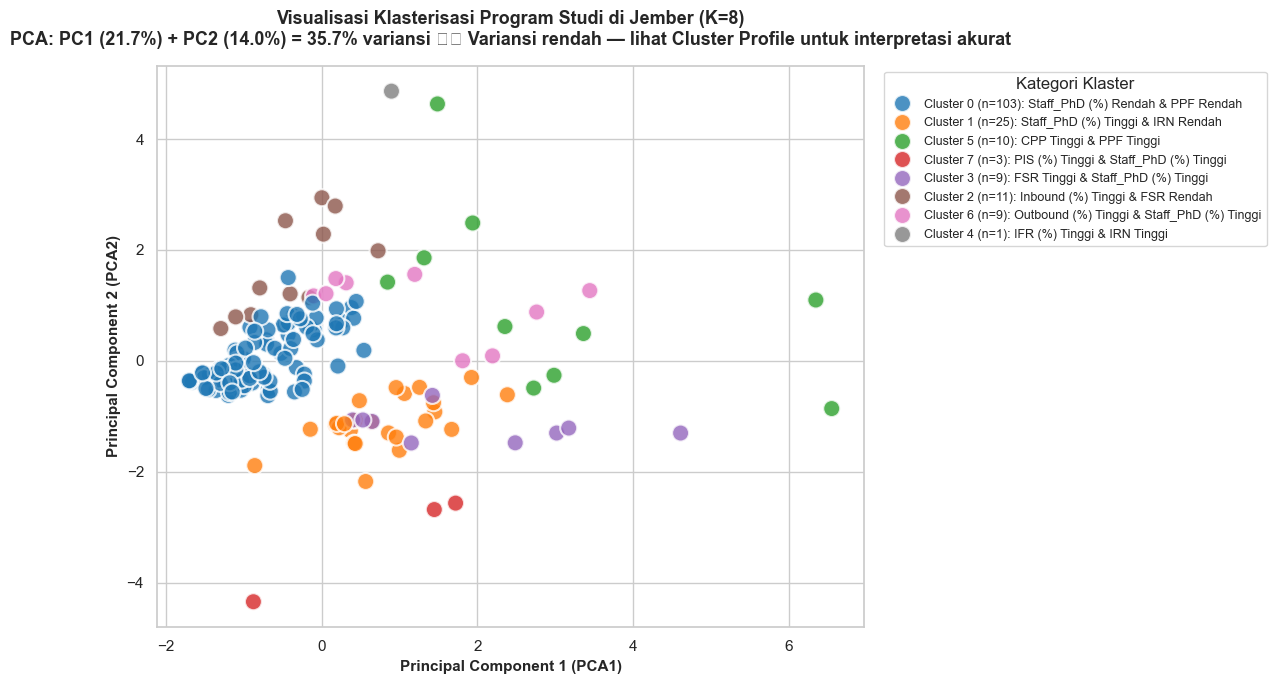

In [64]:
# ============================================================
# CELL 8: K-MEANS CLUSTERIZATION (FINAL)
# ============================================================

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ── 0. Load Data (eksplisit, tidak bergantung pada cell sebelumnya) ──
df = pd.read_excel('data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx')
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)',
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']
X = df[kolom_qs].values

# Folder untuk file excel (Profile & Hasil Klasterisasi)
output_dir_excel = 'data/4_Data_Clusterized/1_Klaster_Umum/2_Hasil_Klasterisasi/'
os.makedirs(output_dir_excel, exist_ok=True)

# Folder khusus untuk gambar
output_dir_images = 'data/4_Data_Clusterized/Images/'
os.makedirs(output_dir_images, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# TENTUKAN K FINAL DI SINI — berdasarkan df_evaluasi_k dari Cell 7
# Pertimbangkan: titik elbow, silhouette tinggi, DAN
# Cluster_Terkecil > 2 (hindari cluster outlier tunggal)
# ══════════════════════════════════════════════════════════════
FINAL_K = k_opt_elbow   # <-- Nilai K Menggunakan Elbow Method
# FINAL_K = k_opt_sil     # <-- Nilai K Menggunakan Silhoutte Score

# ── 1. Eksekusi K-Means ──
kmeans = KMeans(n_clusters=FINAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

cluster_counts = df['Cluster'].value_counts().sort_index()
print(f"=== Distribusi anggota cluster (K={FINAL_K}) ===")
print(cluster_counts)
print(f"Total prodi: {cluster_counts.sum()}")

# ── 2. Diagnostik: Cluster dengan anggota sangat sedikit (n≤2) ──
small_clusters = cluster_counts[cluster_counts <= 2]
if len(small_clusters) > 0:
    print(f"\n⚠️  DITEMUKAN {len(small_clusters)} CLUSTER DENGAN n≤2:")
    print(f"   Catatan: Cluster tunggal/pasangan ini terbentuk karena program studi")
    print(f"   memiliki nilai fitur yang sangat ekstrem (outlier) sehingga K-Means")
    print(f"   mengisolasinya. Ini bukan cluster bermakna secara klasterisasi,")
    print(f"   melainkan cerminan keunikan program studi tersebut.\n")
    for c in small_clusters.index:
        print(f"--- Cluster {c} (n={small_clusters[c]}) ---")
        anggota = df[df['Cluster'] == c][['Program Studi'] + kolom_qs]
        display(anggota)
        for _, row in anggota.iterrows():
            z_vals = row[kolom_qs].astype(float)
            ekstrem = z_vals.abs().sort_values(ascending=False).head(2)
            detail = ", ".join([f"{var} (Z={z_vals[var]:+.2f})" for var in ekstrem.index])
            print(f"  ↳ {row['Program Studi']} → outlier pada: {detail}")
else:
    print("\n✅ Tidak ada cluster dengan anggota ≤2.")

# ── 3. Cluster Profiling ──
cluster_profile = df.groupby('Cluster')[kolom_qs].mean()
cluster_profile.insert(0, 'Jumlah Prodi', cluster_counts)
print("\n=== CLUSTER PROFILE (rata-rata Z-score per cluster) ===")
display(cluster_profile.round(3))

# ── 4. Evaluasi Kualitas Klasterisasi Final ──
sil_final = silhouette_score(X, df['Cluster'])
db_final  = davies_bouldin_score(X, df['Cluster'])
print(f"\n=== EVALUASI KUALITAS KLASTERISASI (K={FINAL_K}) ===")
print(f"  Silhouette Score     : {sil_final:.4f}  (range [-1,1]; semakin tinggi semakin baik)")
print(f"  Davies-Bouldin Index : {db_final:.4f}  (range [0,∞); semakin rendah semakin baik)")

if sil_final >= 0.50:
    print(f"  → Struktur klaster KUAT")
elif sil_final >= 0.25:
    print(f"  → Struktur klaster LEMAH HINGGA SEDANG — interpretasi dengan hati-hati")
else:
    print(f"  → Struktur klaster TIDAK BERMAKNA")

# ── 5. Karakteristik menonjol per cluster (bantuan labeling, data-driven) ──
print("\n=== KARAKTERISTIK MENONJOL PER CLUSTER (Top-2 |Z-score|) ===")
auto_labels = {}
for c in cluster_profile.index:
    profile_c = cluster_profile.loc[c, kolom_qs]
    top2 = profile_c.abs().sort_values(ascending=False).head(2)
    desc_parts = []
    for var in top2.index:
        val = profile_c[var]
        arah = "Tinggi" if val > 0 else "Rendah"
        desc_parts.append(f"{var} {arah}")
        print(f"  Cluster {c} - {var}: {val:+.3f} ({arah})")
    auto_labels[c] = f"Cluster {c} (n={cluster_counts[c]}): " + " & ".join(desc_parts)

# ── 6. Simpan Cluster Profile ──
# ── 6. Simpan Cluster Profile ──
profile_output = f"{output_dir_excel}Cluster_Profile_K-{FINAL_K}.xlsx"
cluster_profile.to_excel(profile_output)
print(f"\nCluster profile disimpan : {profile_output}")

# ── 7. Simpan Hasil Klasterisasi ──
output_file = f"{output_dir_excel}Hasil_Klasterisasi_KMeans_K-{FINAL_K}.xlsx"
df.to_excel(output_file, index=False)
print(f"Data hasil klasterisasi  : {output_file}")

# ── 8. PCA untuk Visualisasi 2D ──
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_
total_var = sum(var_explained) * 100

print(f"\nVariansi dijelaskan PC1 : {var_explained[0]*100:.2f}%")
print(f"Variansi dijelaskan PC2 : {var_explained[1]*100:.2f}%")
print(f"Total (PC1+PC2)         : {total_var:.2f}%")

if total_var < 50:
    print(f"\n⚠️  PERHATIAN VISUALISASI: PC1+PC2 hanya menjelaskan {total_var:.1f}% variansi.")
    print(f"   Scatter plot 2D ini adalah APROKSIMASI KASAR dari struktur klaster 9 dimensi.")
    print(f"   Jarak/pemisahan antar klaster di plot tidak sepenuhnya mencerminkan")
    print(f"   pemisahan sebenarnya. Gunakan Cluster Profile (langkah 3) sebagai")
    print(f"   referensi utama interpretasi, bukan scatter plot ini.")

df_plot = df.copy()
df_plot['PCA1'] = X_pca[:, 0]
df_plot['PCA2'] = X_pca[:, 1]
df_plot['Label Klaster'] = df_plot['Cluster'].map(auto_labels)

# ── 9. Scatter Plot PCA ──
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Label Klaster',
    palette='tab10',
    data=df_plot,
    s=150, alpha=0.8, edgecolor='white', linewidth=1.5
)
plt.title(
    f'Visualisasi Klasterisasi Program Studi di Jember (K={FINAL_K})\n'
    f'PCA: PC1 ({var_explained[0]*100:.1f}%) + PC2 ({var_explained[1]*100:.1f}%)'
    f' = {total_var:.1f}% variansi'
    + (' ⚠️ Variansi rendah — lihat Cluster Profile untuk interpretasi akurat'
       if total_var < 50 else ''),
    fontsize=13, fontweight='bold', pad=15
)
plt.xlabel('Principal Component 1 (PCA1)', fontsize=11, fontweight='bold')
plt.ylabel('Principal Component 2 (PCA2)', fontsize=11, fontweight='bold')
plt.legend(title='Kategori Klaster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()

scatter_output_file = f"{output_dir_images}2_Visualisasi_Klasterisasi_K-{FINAL_K}.png"
plt.savefig(scatter_output_file, dpi=300, bbox_inches='tight')
print(f"\nScatter plot disimpan: {scatter_output_file}")
plt.show()

Opsional Klasterisasi berdasarkan 2 variabel


PROSES: KLASTER STUDENT EXCHANGE


C:\Users\satri\AppData\Local\Temp\ipykernel_17380\1620649805.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


-> K Optimal Terdeteksi (Elbow) : 3
-> Silhouette Score (K=3)  : 0.9020
-> Davies-Bouldin Index (K=3): 0.4600

Distribusi Anggota Klaster:
Cluster
0    151
1      9
2     11

💾 Saved Hasil  : data/4_Data_Clusterized/2_Klaster_Student_Exchange\Hasil_Klasterisasi_Student_Exchange_K3.xlsx
💾 Saved Profile: data/4_Data_Clusterized/2_Klaster_Student_Exchange\Profile_Klaster_Student_Exchange_K3.xlsx

PROSES: KLASTER INTERNATIONALITY READINESS


C:\Users\satri\AppData\Local\Temp\ipykernel_17380\1620649805.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


-> K Optimal Terdeteksi (Elbow) : 3
-> Silhouette Score (K=3)  : 0.9620
-> Davies-Bouldin Index (K=3): 0.2657

Distribusi Anggota Klaster:
Cluster
0    167
1      1
2      3

💾 Saved Hasil  : data/4_Data_Clusterized/3_Klaster_Internationality_Readiness\Hasil_Klasterisasi_Internationality_Readiness_K3.xlsx
💾 Saved Profile: data/4_Data_Clusterized/3_Klaster_Internationality_Readiness\Profile_Klaster_Internationality_Readiness_K3.xlsx

PROSES: KLASTER RESEARCH PERFORMANCE


C:\Users\satri\AppData\Local\Temp\ipykernel_17380\1620649805.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


-> K Optimal Terdeteksi (Elbow) : 4
-> Silhouette Score (K=4)  : 0.4980
-> Davies-Bouldin Index (K=4): 0.7030

Distribusi Anggota Klaster:
Cluster
0    122
1      5
2     43
3      1

💾 Saved Hasil  : data/4_Data_Clusterized/4_Klaster_Research_Performance\Hasil_Klasterisasi_Research_Performance_K4.xlsx
💾 Saved Profile: data/4_Data_Clusterized/4_Klaster_Research_Performance\Profile_Klaster_Research_Performance_K4.xlsx

🎉 SEMUA PROSES SELESAI!
📊 Grafik Gabungan Utama disimpan di: data/4_Data_Clusterized/Images/3_Visualisasi_Gabungan_Bivariat.png


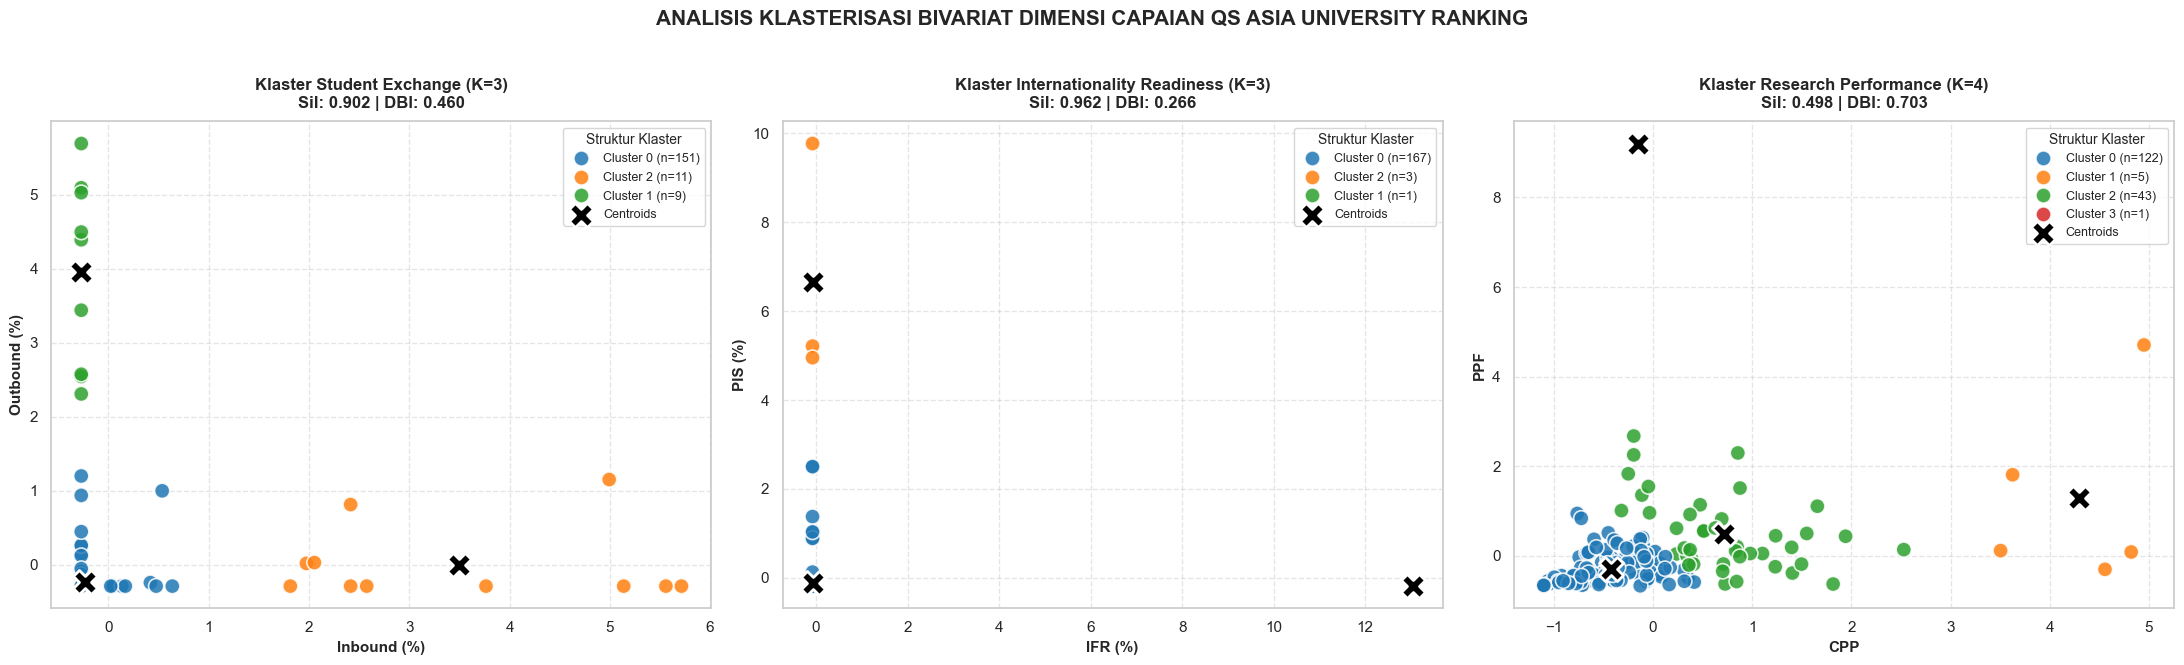

In [67]:
# ── SEABORN & MATPLOTLIP SETTING ──
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ── 0. LOAD DATA SOURCE ──
# Menyesuaikan dengan path dataset normalized Anda
path_source = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx'
df_normalized = pd.read_excel(path_source)

# ── 1. FUNGSI OTOMATISASI ELBOW DETECTOR (Perpendicular Distance) ──
def find_optimal_k_elbow(k_values, inertia_values):
    k_arr = np.array(k_values, dtype=float)
    i_arr = np.array(inertia_values, dtype=float)
    
    # Normalisasi ke skala 0-1 agar adil secara geometri
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    i_norm = (i_arr - i_arr.min()) / (i_arr.max() - i_arr.min())
    
    p1 = np.array([k_norm[0], i_norm[0]])
    p2 = np.array([k_norm[-1], i_norm[-1]])
    
    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], i_norm[i]])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    return k_values[np.argmax(distances)]

# ── 2. DEFINISI CONFIGURASI 3 KOMBINASI KLASTER ──
klaster_configs = {
    'Student_Exchange': {
        'nama': 'Klaster Student Exchange',
        'vars': ['Inbound (%)', 'Outbound (%)'],
        'folder': 'data/4_Data_Clusterized/2_Klaster_Student_Exchange'
    },
    'Internationality_Readiness': {
        'nama': 'Klaster Internationality Readiness',
        'vars': ['IFR (%)', 'PIS (%)'],
        'folder': 'data/4_Data_Clusterized/3_Klaster_Internationality_Readiness'
    },
    'Research_Performance': {
        'nama': 'Klaster Research Performance',
        'vars': ['CPP', 'PPF'],
        'folder': 'data/4_Data_Clusterized/4_Klaster_Research_Performance'
    }
}

# SETUP GRAFIK BERSAMAAN (1 Baris, 3 Kolom)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
max_k_search = 10
k_range = list(range(1, max_k_search + 1))

# ── 3. LOOPING EKSEKUSI UNTUK SETIAP KOMBINASI ──
for idx, (key, config) in enumerate(klaster_configs.items()):
    print(f"\n=======================================================")
    print(f"PROSES: {config['nama'].upper()}")
    print(f"=======================================================")
    
    # Buat direktori jika belum ada
    os.makedirs(config['folder'], exist_ok=True)
    
    # Ambil matriks fitur (hanya 2 variabel)
    X_sub = df_normalized[config['vars']].values
    
    # Pencarian K Optimal
    wcss = []
    sil_scores = []
    for k in k_range:
        kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels_test = kmeans_test.fit_predict(X_sub)
        wcss.append(kmeans_test.inertia_)
        if k >= 2:
            sil_scores.append(silhouette_score(X_sub, labels_test))
            
    # Tentukan K Final menggunakan geometri Elbow
    k_final = find_optimal_k_elbow(k_range, wcss)
    sil_final = silhouette_score(X_sub, KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10).fit_predict(X_sub))
    dbi_final = davies_bouldin_score(X_sub, KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10).fit_predict(X_sub))
    
    print(f"-> K Optimal Terdeteksi (Elbow) : {k_final}")
    print(f"-> Silhouette Score (K={k_final})  : {sil_final:.4f}")
    print(f"-> Davies-Bouldin Index (K={k_final}): {dbi_final:.4f}")
    
    # Eksekusi Final K-Means
    kmeans_final = KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10)
    df_result = df_normalized.copy()
    df_result['Cluster'] = kmeans_final.fit_predict(X_sub)
    
    # Distribusi Anggota
    counts = df_result['Cluster'].value_counts().sort_index()
    print("\nDistribusi Anggota Klaster:")
    print(counts.to_string())
    
    # Pembuatan Cluster Profile (Rata-rata Z-Score)
    profile = df_result.groupby('Cluster')[config['vars']].mean()
    profile.insert(0, 'Jumlah Prodi', counts)
    
    # SIMPAN OUTPUT KE EXCEL
    file_hasil = os.path.join(config['folder'], f"Hasil_Klasterisasi_{key}_K{k_final}.xlsx")
    file_profile = os.path.join(config['folder'], f"Profile_Klaster_{key}_K{k_final}.xlsx")
    
    df_result.to_excel(file_hasil, index=False)
    profile.to_excel(file_profile)
    print(f"\n💾 Saved Hasil  : {file_hasil}")
    print(f"💾 Saved Profile: {file_profile}")
    
    # PLOT KE SUBPLOT (GRAFIK BERSAMAAN)
    ax = axes[idx]
    # Membuat label klaster dinamis untuk legenda plot
    df_result['Label_Legenda'] = df_result['Cluster'].apply(lambda c: f"Cluster {c} (n={counts[c]})")
    
    sns.scatterplot(
        x=config['vars'][0], 
        y=config['vars'][1], 
        hue='Label_Legenda',
        palette='tab10', 
        data=df_result, 
        s=120, 
        alpha=0.85, 
        edgecolor='white', 
        linewidth=1.2,
        ax=ax
    )
    
    # Plot Centroid
    centroids = kmeans_final.cluster_centers_
    ax.scatter(
        centroids[:, 0], centroids[:, 1], 
        s=300, c='black', marker='X', edgecolor='white', linewidth=2, 
        label='Centroids'
    )
    
    ax.set_title(f"{config['nama']} (K={k_final})\nSil: {sil_final:.3f} | DBI: {dbi_final:.3f}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(config['vars'][0], fontsize=11, fontweight='semibold')
    ax.set_ylabel(config['vars'][1], fontsize=11, fontweight='semibold')
    ax.legend(title="Struktur Klaster", loc='upper right', fontsize=9, title_fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Finalisasi tata letak seluruh grafik panel
plt.suptitle('ANALISIS KLASTERISASI BIVARIAT DIMENSI CAPAIAN QS ASIA UNIVERSITY RANKING', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan grafik gabungan utama
main_plot_path = r'data/4_Data_Clusterized/Images/3_Visualisasi_Gabungan_Bivariat.png'
plt.savefig(main_plot_path, dpi=300, bbox_inches='tight')
print(f"\n=======================================================")
print(f"🎉 SEMUA PROSES SELESAI!")
print(f"📊 Grafik Gabungan Utama disimpan di: {main_plot_path}")
print(f"=======================================================")
plt.show()